<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            7. Aplicación de algoritmos de clasificación para la detección temprana de abandono laboral
        </td>
    </tr>
</table>

In [2]:
import pandas as pd
import os
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

El conjunto de datos de predicción de rotación de empleados contiene información de 10,000 empleados, diseñado para el modelado predictivo y el análisis de la rotación laboral. Incluye una variedad de métricas demográficas, laborales y de desempeño que ayudan a comprender los factores que contribuyen a la salida o abandono de los empleados en una organización. Aplicación de algoritmos de clasificación para la detección temprana. Vas a usar `clasificacion.csv`.

### Variables y Descripciones:
- **Employee_ID**: Identificador único para cada empleado.
- **Age**: Edad del empleado.
- **Gender**: Género del empleado.
- **Marital_Status**: Estado civil del empleado: soltero, casado o divorciado.
- **Department**: Departamento en el que trabaja el empleado.
- **Job_Role**: Rol específico dentro del departamento.
- **Job_Level**: Nivel dentro de la jerarquía organizacional.
- **Monthly_Income**: Salario mensual del empleado.
- **Hourly_Rate**: Tarifa por hora para empleados que trabajan por hora.
- **Years_at_Company**: Número de años que el empleado ha trabajado en la empresa.
- **Years_in_Current_Role**: Número de años que el empleado ha permanecido en su rol actual.
- **Years_Since_Last_Promotion**: Tiempo transcurrido desde la última promoción del empleado.
- **Work_Life_Balance**: Valoración del equilibrio entre la vida laboral y personal.
- **Job_Satisfaction**: Valoración de la satisfacción laboral en una escala de 1 a 5.
- **Performance_Rating**: Valoración del desempeño en una escala de 1 a 5.
- **Training_Hours_Last_Year**: Número de horas de capacitación completadas durante el último año.
- **Overtime**: Indica si el empleado trabaja horas extra: sí o no.
- **Project_Count**: Número de proyectos gestionados por el empleado.
- **Average_Hours_Worked_Per_Week**: Promedio de horas trabajadas por semana.
- **Absenteeism**: Número de días que el empleado estuvo ausente durante el último año.
- **Work_Environment_Satisfaction**: Valoración de la satisfacción con el ambiente laboral.
- **Relationship_with_Manager**: Valoración de la relación con el gerente o jefe inmediato.
- **Job_Involvement**: Valoración del nivel de involucramiento en el trabajo.
- **Distance_From_Home**: Distancia desde el hogar hasta el lugar de trabajo, en kilómetros.
- **Number_of_Companies_Worked**: Número total de empresas en las que ha trabajado el empleado.
- **Attrition**: Variable objetivo que indica si el empleado dejó la empresa: sí o no.

## Desarrollo de la Actividad
a) Cargar y explorar el conjunto de datos.
b) Representar gráficamente las variables clave que conforman el dataset.
c) Preparar los datos convirtiendo variables categóricas en numéricas (Dummies) y particionar el conjunto en un 25% para validación y el resto para entrenamiento.
d) Ajustar un modelo de Regresión Logística y evaluar sus métricas de bondad de ajuste.
e) Implementar el método de K-Vecinos más cercanos (KNN) optimizando el parámetro K mediante validación cruzada.
f) Implementar un modelo de Clasificación mediante Árboles de Decisión optimizando su profundidad.
g) Comparar los modelos y clasificar una observación representativa obtenida mediante la media de los datos independientes.

### a) Carga y Exploración de Datos

In [3]:
# Carga de datos
df = pd.read_csv('clasificacion.csv')
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [4]:
# Estructura del dataset y tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    1000 non-null   int64
 1   Age                            1000 non-null   int64
 2   Gender                         1000 non-null   str  
 3   Marital_Status                 1000 non-null   str  
 4   Department                     1000 non-null   str  
 5   Job_Role                       1000 non-null   str  
 6   Job_Level                      1000 non-null   int64
 7   Monthly_Income                 1000 non-null   int64
 8   Hourly_Rate                    1000 non-null   int64
 9   Years_at_Company               1000 non-null   int64
 10  Years_in_Current_Role          1000 non-null   int64
 11  Years_Since_Last_Promotion     1000 non-null   int64
 12  Work_Life_Balance              1000 non-null   int64
 13  Job_Satisfaction              

### b) Análisis Gráfico de los Datos
Se evalúa el comportamiento de variables críticas como los ingresos mensuales en función de la variable objetivo (`Attrition`).

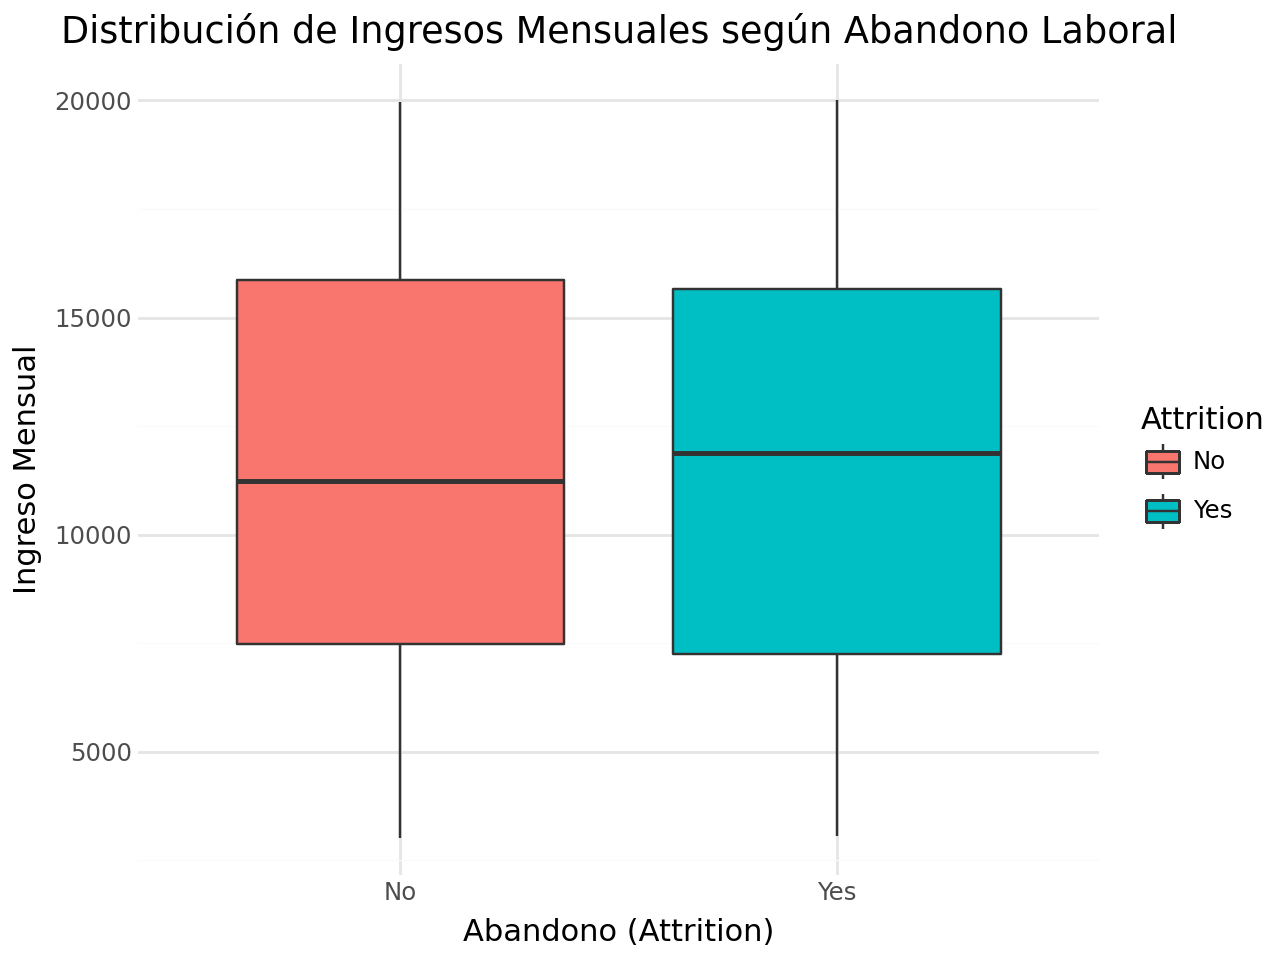

In [5]:
# Gráfico: Distribución de Ingresos Mensuales por Attrition usando plotnine
(ggplot(df, aes(x='Attrition', y='Monthly_Income', fill='Attrition')) +
 geom_boxplot() +
 theme_minimal() +
 labs(title='Distribución de Ingresos Mensuales según Abandono Laboral',
      x='Abandono (Attrition)', y='Ingreso Mensual'))

### c) Preparación y Partición de Datos
Transformamos la variable objetivo y las variables explicativas categóricas a numéricas mediante codificación de variables indicadoras (Dummies).

In [6]:
# Convertir variable objetivo a binaria (0: No, 1: Yes)
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})

# Selección de variables predictoras numéricas y categóricas para el modelado
features = ['Age', 'Gender', 'Marital_Status', 'Department', 'Job_Level', 
            'Monthly_Income', 'Years_at_Company', 'Work_Life_Balance', 
            'Job_Satisfaction', 'Overtime', 'Average_Hours_Worked_Per_Week', 'Absenteeism']

X = df[features]
y = df['Attrition']

# Aplicación de variables Dummies para las cualitativas
X = pd.get_dummies(X, drop_first=True)

# Partición del conjunto de datos (25% Validación, 75% Entrenamiento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Dimensiones de Entrenamiento:", X_train.shape)
print("Dimensiones de Validación:", X_test.shape)

Dimensiones de Entrenamiento: (750, 16)
Dimensiones de Validación: (250, 16)


### d) Modelo de Regresión Logística

In [7]:
# Ajuste del modelo por Regresión Logística usando Statsmodels
X_train_sm = sm.add_constant(X_train.astype(float))
log_reg_model = sm.Logit(y_train, X_train_sm).fit()
print(log_reg_model.summary())

Optimization terminated successfully.
         Current function value: 0.493947
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                  750
Model:                          Logit   Df Residuals:                      733
Method:                           MLE   Df Model:                           16
Date:                Fri, 29 May 2026   Pseudo R-squ.:                 0.01652
Time:                        10:30:35   Log-Likelihood:                -370.46
converged:                       True   LL-Null:                       -376.68
Covariance Type:            nonrobust   LLR p-value:                    0.7127
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -3.1952      0.838     -3.814      0.

In [8]:
# Predicciones en el conjunto de prueba
X_test_sm = sm.add_constant(X_test.astype(float))
y_pred_prob = log_reg_model.predict(X_test_sm)
y_pred_logistic = (y_pred_prob >= 0.5).astype(int)

# Matriz de confusión
conf_matrix_log = confusion_matrix(y_test, y_pred_logistic)
print("Matriz de Confusión Logística:\n", conf_matrix_log)

Matriz de Confusión Logística:
 [[212   0]
 [ 38   0]]


In [9]:
# Métricas de bondad del ajuste
accuracy_log = accuracy_score(y_test, y_pred_logistic)
precision_log = precision_score(y_test, y_pred_logistic)
recall_log = recall_score(y_test, y_pred_logistic)
f1_log = f1_score(y_test, y_pred_logistic)

metrics_log_df = pd.DataFrame({
    'Métricas': ['Accuracy Score', 'Precisión', 'Recall', 'F1 Score'],
    'Valores': [accuracy_log, precision_log, recall_log, f1_log]
})
metrics_log_df

,Métricas,Valores
0,Accuracy Score,0.848
1,Precisión,0.000
2,Recall,0.000
3,F1 Score,0.000


### e) Método de los K-Vecinos Más Cercanos (KNN)
Procedemos a estandarizar las variables predictoras ya que este método se basa en el cálculo de distancias. Posteriormente buscaremos el parámetro K óptimo empleando validación cruzada.

In [10]:
# Estandarización de variables independientes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Búsqueda del K óptimo mediante validación cruzada (Rango de impares 1 a 15)
k_valores = range(1, 16, 2)
cv_scores = []

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

k_optimo = k_valores[np.argmax(cv_scores)]
print("El parámetro K óptimo que maximiza el accuracy score es:", k_optimo)

El parámetro K óptimo que maximiza el accuracy score es: 15


In [11]:
# Construir el clasificador con el valor de K óptimo
model_KNN_opt = KNeighborsClassifier(n_neighbors=k_optimo)
model_KNN_opt.fit(X_train_scaled, y_train)
y_pred_knn = model_KNN_opt.predict(X_test_scaled)

# Métricas KNN
metrics_knn_df = pd.DataFrame({
    'Métricas': ['Accuracy Score', 'Precisión', 'Recall', 'F1 Score'],
    'Valores': [accuracy_score(y_test, y_pred_knn), precision_score(y_test, y_pred_knn), 
                recall_score(y_test, y_pred_knn), f1_score(y_test, y_pred_knn)]
})
metrics_knn_df

,Métricas,Valores
0,Accuracy Score,0.848
1,Precisión,0.000
2,Recall,0.000
3,F1 Score,0.000


### f) Modelo de Árbol de Decisión
Se evalúa la optimización del modelo mediante un árbol restringido por profundidad máxima mediante validación cruzada para evitar sobreajuste.

In [12]:
# Identificación de la profundidad óptima
profundidades = range(1, 11)
tree_scores = []

for p in profundidades:
    tree_test = DecisionTreeClassifier(max_depth=p, random_state=42)
    scores = cross_val_score(tree_test, X_train, y_train, cv=5, scoring='accuracy')
    tree_scores.append(scores.mean())

depth_optima = profundidades[np.argmax(tree_scores)]
print("La profundidad máxima óptima para el árbol es:", depth_optima)

La profundidad máxima óptima para el árbol es: 1


In [13]:
# Construir el modelo final del árbol de decisión
model_tree_opt = DecisionTreeClassifier(max_depth=depth_optima, random_state=42)
model_tree_opt.fit(X_train, y_train)
y_pred_tree = model_tree_opt.predict(X_test)

# Métricas del Árbol de Decisión
metrics_tree_df = pd.DataFrame({
    'Métricas': ['Accuracy Score', 'Precisión', 'Recall', 'F1 Score'],
    'Valores': [accuracy_score(y_test, y_pred_tree), precision_score(y_test, y_pred_tree), 
                recall_score(y_test, y_pred_tree), f1_score(y_test, y_pred_tree)]
})
metrics_tree_df

,Métricas,Valores
0,Accuracy Score,0.848
1,Precisión,0.000
2,Recall,0.000
3,F1 Score,0.000


### g) Clasificación para la Observación Representativa (Media)
Seleccionamos el mejor modelo clasificador con base en el rendimiento global y realizamos la predicción con la media de las observaciones del conjunto de entrenamiento.

In [14]:
# Obtener la media para clasificar la observación representativa
X_media = np.mean(X_train, axis=0)

# Realizar la clasificación con el modelo de Árbol de Decisión Optimizado
pred_media = model_tree_opt.predict(X_media.values.reshape(1, -1))
print("El empleado representativo basado en la media se clasifica como:", pred_media)

El empleado representativo basado en la media se clasifica como: [0]


## Fin de la Investigación